In [1]:
# Task 04 - Image-to-Image Translation with cGAN (Pix2Pix)

import torch

print("PyTorch version:", torch.__version__)

if torch.cuda.is_available():
    print("GPU available:", torch.cuda.get_device_name(0))
else:
    print("GPU not available. Please enable T4 GPU.")

PyTorch version: 2.11.0+cu128
GPU available: Tesla T4


In [3]:
# Step 1 : Install required libraries

!pip install -q torch torchvision matplotlib pillow numpy

print("Required libraries installed successfully!")

Required libraries installed successfully!


In [4]:
# Step 2: Import libraries

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

print("All libraries imported successfully!")

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using device:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("Using CPU")

All libraries imported successfully!
Using device: Tesla T4


In [15]:
# Step 4A: Install Hugging Face dataset tools

!pip install -q datasets huggingface_hub

print("Hugging Face tools installed successfully!")

Hugging Face tools installed successfully!


In [24]:
# Step 5: Mount Google Drive

from google.colab import drive

drive.mount('/content/drive')

print("Google Drive mounted successfully!")

Mounted at /content/drive
Google Drive mounted successfully!


In [27]:
# Step 6: Find archive.zip in Google Drive

import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.lower() == "archive.zip":
            print("Found:", os.path.join(root, file))

In [28]:
# Step 7: Extract the Facades dataset from Google Drive

import os
import zipfile

# Search for archive.zip
zip_path = None

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.lower() == "archive.zip":
            zip_path = os.path.join(root, file)
            break
    if zip_path:
        break

if zip_path is None:
    print("❌ archive.zip not found in Google Drive.")
else:
    print("ZIP file found:")
    print(zip_path)

    extract_path = "/content/facades_dataset"

    os.makedirs(extract_path, exist_ok=True)

    print("\nExtracting dataset...")

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)

    print("\n✅ Dataset extracted successfully!")
    print("Location:", extract_path)

    print("\nExtracted contents:")
    for item in os.listdir(extract_path):
        print(" -", item)

ZIP file found:
/content/drive/MyDrive/Colab Notebooks/archive.zip/archive.zip

Extracting dataset...

✅ Dataset extracted successfully!
Location: /content/facades_dataset

Extracted contents:
 - facades


In [29]:
# Step 8: Check the extracted Facades dataset

import os

base_path = "/content/facades_dataset"

print("Dataset structure:\n")

for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:5]:
        print(f"{indent}  {file}")

    if level >= 2:
        dirs[:] = []

Dataset structure:

facades_dataset/
  facades/
    val/
      2.jpg
      78.jpg
      62.jpg
      91.jpg
      90.jpg
    test/
      2.jpg
      78.jpg
      62.jpg
      91.jpg
      90.jpg
    train/
      2.jpg
      78.jpg
      121.jpg
      62.jpg
      91.jpg


Total image files found: 606
Sample image:
/content/facades_dataset/facades/val/2.jpg


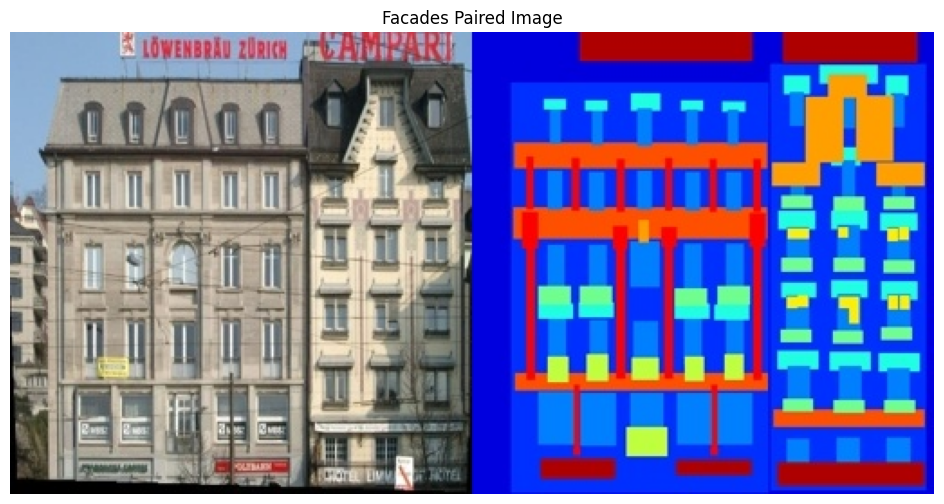

In [30]:
# Step 9: Find and display Facades images

import os
import glob
import matplotlib.pyplot as plt
from PIL import Image

base_path = "/content/facades_dataset"

# Find all image files
image_files = []

for extension in ["*.jpg", "*.jpeg", "*.png"]:
    image_files.extend(
        glob.glob(base_path + "/**/" + extension, recursive=True)
    )

print("Total image files found:", len(image_files))

# Display the first image
if len(image_files) > 0:
    image_path = image_files[0]

    print("Sample image:")
    print(image_path)

    image = Image.open(image_path)

    plt.figure(figsize=(12, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Facades Paired Image")
    plt.show()

else:
    print("No image files found.")

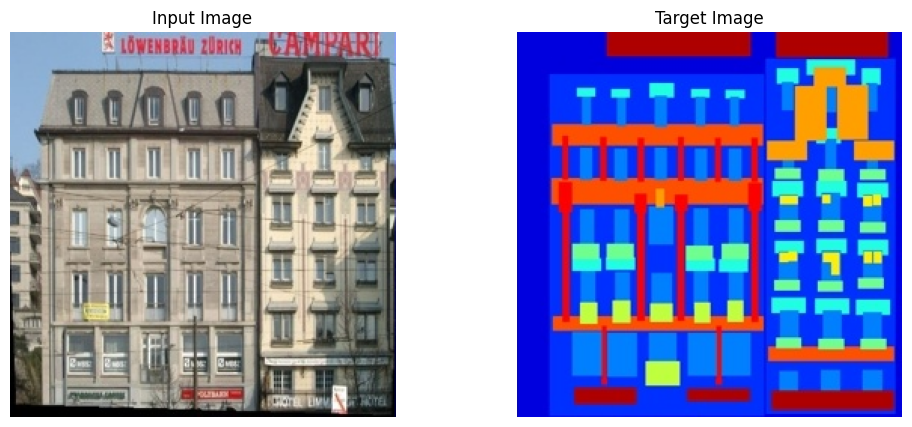

Original paired image size: (512, 256)
Input image size: (256, 256)
Target image size: (256, 256)


In [31]:
# Step 10: Split a paired Facades image into input and target

from PIL import Image
import matplotlib.pyplot as plt

# Load the first Facades image
image_path = image_files[0]
paired_image = Image.open(image_path).convert("RGB")

# Get image dimensions
width, height = paired_image.size

# Split the image into two equal parts
input_image = paired_image.crop((0, 0, width // 2, height))
target_image = paired_image.crop((width // 2, 0, width, height))

# Display input and target images
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(input_image)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(target_image)
plt.title("Target Image")
plt.axis("off")

plt.show()

print("Original paired image size:", paired_image.size)
print("Input image size:", input_image.size)
print("Target image size:", target_image.size)

In [32]:
# Step 11: Create PyTorch Dataset and DataLoader

class FacadesDataset(Dataset):
    def __init__(self, image_paths, image_size=128):
        self.image_paths = image_paths

        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5),
                                 (0.5, 0.5, 0.5))
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image = Image.open(self.image_paths[index]).convert("RGB")

        width, height = image.size

        # Split paired image into input and target
        input_image = image.crop((0, 0, width // 2, height))
        target_image = image.crop((width // 2, 0, width, height))

        input_image = self.transform(input_image)
        target_image = self.transform(target_image)

        return input_image, target_image


# Create dataset
facades_dataset = FacadesDataset(image_files)

# Create DataLoader
batch_size = 8

dataloader = DataLoader(
    facades_dataset,
    batch_size=batch_size,
    shuffle=True
)

print("PyTorch Dataset created successfully!")
print("Total image pairs:", len(facades_dataset))
print("Batch size:", batch_size)
print("Number of batches:", len(dataloader))

PyTorch Dataset created successfully!
Total image pairs: 606
Batch size: 8
Number of batches: 76


In [33]:
# Step 12: Build the Pix2Pix Generator (U-Net)

class UNetGenerator(nn.Module):
    def __init__(self):
        super(UNetGenerator, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


# Create Generator
generator = UNetGenerator().to(device)

print("Generator created successfully!")
print("Generator is running on:", device)

Generator created successfully!
Generator is running on: cuda


In [34]:
# Step 13: Build the Pix2Pix PatchGAN Discriminator

class PatchGANDiscriminator(nn.Module):
    def __init__(self):
        super(PatchGANDiscriminator, self).__init__()

        self.model = nn.Sequential(
            # Input: input image + target/generated image
            nn.Conv2d(6, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 1, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            # PatchGAN output
            nn.Conv2d(512, 1, 4, 1, 1)
        )

    def forward(self, input_image, target_image):
        # Concatenate input and target along channel dimension
        combined = torch.cat((input_image, target_image), dim=1)
        return self.model(combined)


# Create Discriminator
discriminator = PatchGANDiscriminator().to(device)

print("Discriminator created successfully!")
print("Discriminator is running on:", device)

Discriminator created successfully!
Discriminator is running on: cuda


In [35]:
# Step 14: Define Loss Functions and Optimizers

# Adversarial loss
criterion_GAN = nn.BCEWithLogitsLoss()

# L1 loss for image reconstruction
criterion_L1 = nn.L1Loss()

# Optimizers
optimizer_G = optim.Adam(
    generator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

# Weight for L1 reconstruction loss
lambda_L1 = 100

print("Loss functions and optimizers created successfully!")
print("Learning rate: 0.0002")
print("L1 loss weight:", lambda_L1)

Loss functions and optimizers created successfully!
Learning rate: 0.0002
L1 loss weight: 100


In [36]:
# Step 15: Train the Pix2Pix cGAN

num_epochs = 10

print("Starting cGAN training...")
print("Number of epochs:", num_epochs)

for epoch in range(num_epochs):

    generator.train()
    discriminator.train()

    total_g_loss = 0
    total_d_loss = 0

    for input_image, target_image in dataloader:

        input_image = input_image.to(device)
        target_image = target_image.to(device)

        # ==========================================
        # Train Discriminator
        # ==========================================

        optimizer_D.zero_grad()

        # Real pair
        real_output = discriminator(input_image, target_image)

        real_labels = torch.ones_like(real_output)
        loss_D_real = criterion_GAN(real_output, real_labels)

        # Generate fake image
        fake_image = generator(input_image)

        # Fake pair
        fake_output = discriminator(input_image, fake_image.detach())

        fake_labels = torch.zeros_like(fake_output)
        loss_D_fake = criterion_GAN(fake_output, fake_labels)

        # Total discriminator loss
        loss_D = (loss_D_real + loss_D_fake) * 0.5

        loss_D.backward()
        optimizer_D.step()

        # ==========================================
        # Train Generator
        # ==========================================

        optimizer_G.zero_grad()

        fake_image = generator(input_image)

        fake_output = discriminator(input_image, fake_image)

        # Adversarial loss
        loss_G_GAN = criterion_GAN(
            fake_output,
            torch.ones_like(fake_output)
        )

        # Reconstruction loss
        loss_G_L1 = criterion_L1(fake_image, target_image)

        # Total generator loss
        loss_G = loss_G_GAN + lambda_L1 * loss_G_L1

        loss_G.backward()
        optimizer_G.step()

        total_g_loss += loss_G.item()
        total_d_loss += loss_D.item()

    avg_g_loss = total_g_loss / len(dataloader)
    avg_d_loss = total_d_loss / len(dataloader)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"| Generator Loss: {avg_g_loss:.4f} "
        f"| Discriminator Loss: {avg_d_loss:.4f}"
    )

print("\nTraining completed successfully!")

Starting cGAN training...
Number of epochs: 10
Epoch [1/10] | Generator Loss: 55.6850 | Discriminator Loss: 0.2205
Epoch [2/10] | Generator Loss: 44.8046 | Discriminator Loss: 0.2258
Epoch [3/10] | Generator Loss: 43.5270 | Discriminator Loss: 0.1923
Epoch [4/10] | Generator Loss: 42.3162 | Discriminator Loss: 0.2573
Epoch [5/10] | Generator Loss: 41.3772 | Discriminator Loss: 0.3073
Epoch [6/10] | Generator Loss: 40.0382 | Discriminator Loss: 0.2892
Epoch [7/10] | Generator Loss: 38.8916 | Discriminator Loss: 0.3165
Epoch [8/10] | Generator Loss: 37.2484 | Discriminator Loss: 0.3165
Epoch [9/10] | Generator Loss: 36.0641 | Discriminator Loss: 0.2986
Epoch [10/10] | Generator Loss: 34.9521 | Discriminator Loss: 0.3557

Training completed successfully!


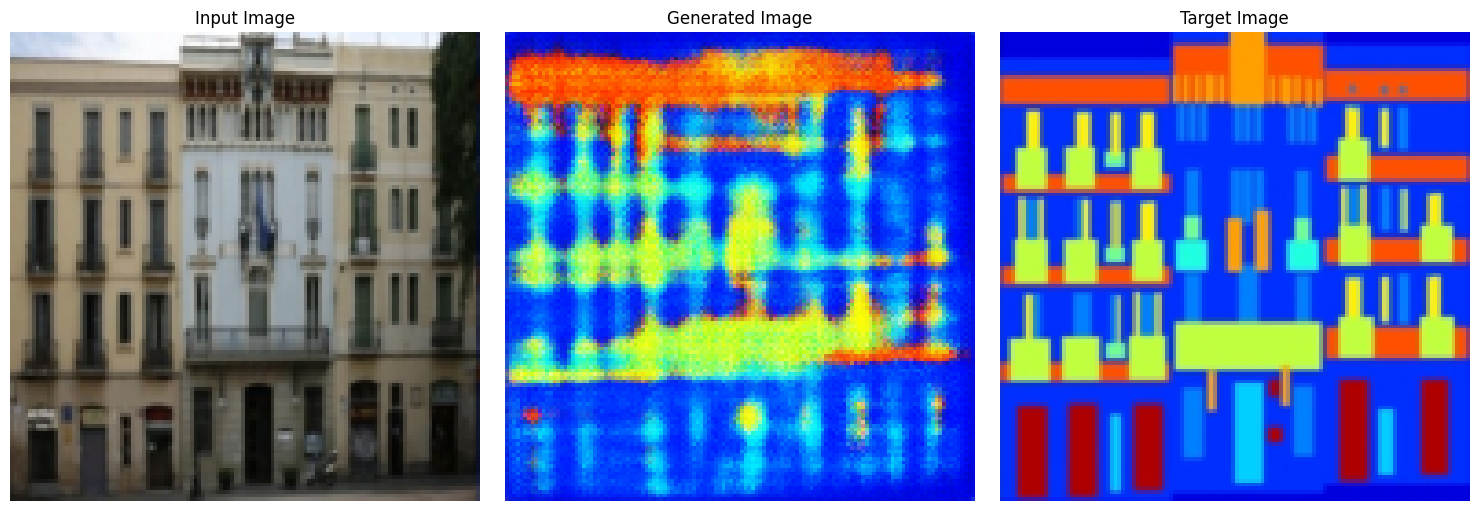

Image comparison completed successfully!


In [37]:
# Step 16: Compare Input, Generated and Target Images

generator.eval()

with torch.no_grad():
    input_batch, target_batch = next(iter(dataloader))

    input_sample = input_batch[0].unsqueeze(0).to(device)
    target_sample = target_batch[0]

    generated_sample = generator(input_sample).cpu().squeeze(0)

# Convert images from [-1, 1] back to [0, 1]
input_display = input_sample.cpu().squeeze(0) * 0.5 + 0.5
generated_display = generated_sample * 0.5 + 0.5
target_display = target_sample * 0.5 + 0.5

# Convert CHW -> HWC
input_display = input_display.permute(1, 2, 0).numpy()
generated_display = generated_display.permute(1, 2, 0).numpy()
target_display = target_display.permute(1, 2, 0).numpy()

# Display comparison
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(np.clip(input_display, 0, 1))
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(np.clip(generated_display, 0, 1))
plt.title("Generated Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(np.clip(target_display, 0, 1))
plt.title("Target Image")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Image comparison completed successfully!")

In [38]:
# Step 17: Save the generated image

from PIL import Image

output_dir = "/content/task4_results"
os.makedirs(output_dir, exist_ok=True)

# Convert generated image to 0-255
generated_array = (
    np.clip(generated_display, 0, 1) * 255
).astype(np.uint8)

generated_image = Image.fromarray(generated_array)

output_path = os.path.join(
    output_dir,
    "generated_facades_image.png"
)

generated_image.save(output_path)

print("Generated image saved successfully!")
print("File:", output_path)

Generated image saved successfully!
File: /content/task4_results/generated_facades_image.png


In [39]:
# Step 18: Save the trained Generator

model_path = "/content/task4_results/pix2pix_generator.pth"

torch.save(generator.state_dict(), model_path)

print("Generator model saved successfully!")
print("Model file:", model_path)

Generator model saved successfully!
Model file: /content/task4_results/pix2pix_generator.pth


In [40]:
# Step 19: Package Task-04 results

import shutil
import os

results_folder = "/content/task4_results"
zip_path = "/content/PRODIGY_GA_04_results.zip"

if os.path.exists(zip_path):
    os.remove(zip_path)

shutil.make_archive(
    "/content/PRODIGY_GA_04_results",
    "zip",
    results_folder
)

print("Task-04 results packaged successfully!")
print("ZIP file:", zip_path)

print("\nFiles included:")
for file in os.listdir(results_folder):
    print(" -", file)

Task-04 results packaged successfully!
ZIP file: /content/PRODIGY_GA_04_results.zip

Files included:
 - pix2pix_generator.pth
 - generated_facades_image.png
